In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/legal_text_classification.csv")

print(df.shape)
df.head()

(24985, 4)


,case_id,case_outcome,case_title,case_text
0,Case1,cited,Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Lt...,Ordinarily that discretion will be exercised s...
1,Case2,cited,Black v Lipovac [1998] FCA 699 ; (1998) 217 AL...,The general principles governing the exercise ...
2,Case3,cited,Colgate Palmolive Co v Cussons Pty Ltd (1993) ...,Ordinarily that discretion will be exercised s...
3,Case4,cited,Dais Studio Pty Ltd v Bullett Creative Pty Ltd...,The general principles governing the exercise ...
4,Case5,cited,Dr Martens Australia Pty Ltd v Figgins Holding...,The preceding general principles inform the ex...


In [2]:
df["text_length"] = df["case_text"].astype(str).apply(len)

print(df["text_length"].describe())

count     24985.000000
mean       2632.287693
std        6748.696470
min           3.000000
25%         830.000000
50%        1399.000000
75%        2519.000000
max      133561.000000
Name: text_length, dtype: float64


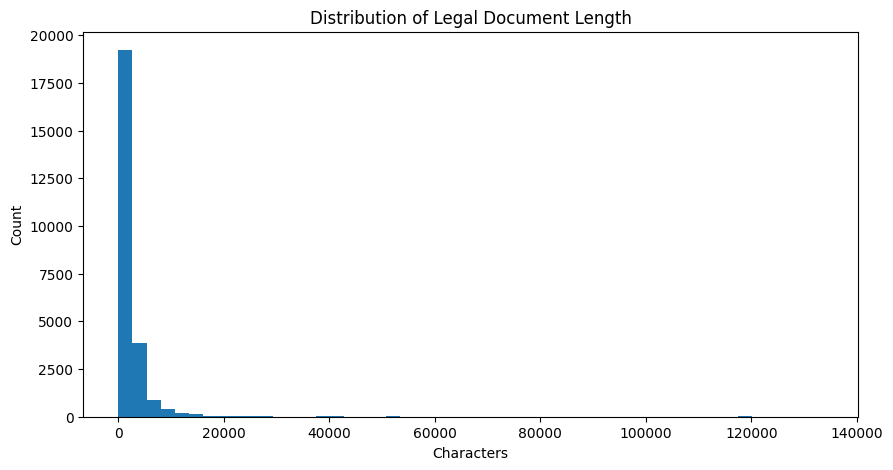

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["text_length"], bins=50)
plt.title("Distribution of Legal Document Length")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

In [4]:
print(df["case_outcome"].value_counts())

case_outcome
cited            12219
referred to       4384
applied           2448
followed          2256
considered        1712
discussed         1024
distinguished      608
related            113
affirmed           113
approved           108
Name: count, dtype: int64


In [5]:
df[["case_title","case_text"]].sample(5, random_state=42)

,case_title,case_text
15561,Knight v Beyond Properties Pty Ltd [2007] FCAF...,Relevant principles in the context of claimed ...
9253,Powell v Evreniades (1989) 21 FCR 252,The term 'serious hardship' is not defined in ...
8409,Wigan v English and Scottish Law Life Assuranc...,to sue for an antecedent debt pursuant to an a...
11078,Roufos v Andrea (1981) 57 FLR 10,In determining whether a bankruptcy notice cou...
1675,Alister v The Queen (1984) 154 CLR 404,Commonwealth v Northern Land Council [1993] HC...


In [6]:
print("Before Cleaning:")
print(df.shape)

df_clean = df.dropna(subset=["case_text"])

print("\nAfter Cleaning:")
print(df_clean.shape)

print("\nRemoved Rows:")
print(len(df) - len(df_clean))

Before Cleaning:
(24985, 5)

After Cleaning:
(24809, 5)

Removed Rows:
176


In [7]:
df_clean["case_text"] = (
    df_clean["case_text"]
    .astype(str)
    .str.replace("\n", " ", regex=False)
    .str.replace("\t", " ", regex=False)
    .str.strip()
)

C:\Users\tanis\AppData\Local\Temp\ipykernel_10992\847104777.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["case_text"] = (


In [8]:
print(df_clean["case_text"].isnull().sum())

0


In [9]:
df_clean.to_csv(
    "../data/processed/legal_cleaned.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully
